# CSP ATB 2024 — Envelope multipliers (moderate × multiplier)

This notebook:
1) Loads **advanced / moderate / conservative** CSP CSVs from ReEDS raw GitHub links  
2) Supports CSP files that use `type` as the technology id column (e.g., `csp1`, `csp2`, …)  
3) Fits least-squares multipliers mapping `moderate → advanced` and `moderate → conservative` over years ≥ `START_YEAR`  
4) Plots an envelope that **starts at START_YEAR**  
5) Saves a multipliers table.

---

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# ---------------------------
# CONFIG
# ---------------------------
FILE_URLS = {
    "advanced": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/csp_ATB_2024_advanced.csv",
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/csp_ATB_2024_moderate.csv",
    "conservative": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/csp_ATB_2024_conservative.csv",
}

# CSP files typically use `type` as the tech id column, but we auto-detect.
TECH_COL_CANDIDATES = ["type", "i", "tech", "technology"]

# Which technologies to process (values in TECH_COL).
# Leave as None to auto-detect all unique values from the moderate file.
TECH_LIST = None

METRICS = ["capcost", "fom", "vom"]  # CSP CSVs shown don't include heatrate

START_YEAR = 2025

SAVE_CSV = True
OUT_CSV = "csp_envelope_multipliers.csv"

In [14]:
def detect_tech_col(df: pd.DataFrame, candidates: list[str]) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find a tech id column among: {candidates}. Found columns: {list(df.columns)}")

def load_from_urls(urls: dict) -> tuple[pd.DataFrame, str]:
    dfs = []
    tech_col = None
    for scen, url in urls.items():
        df = pd.read_csv(url)
        df["scenario"] = scen
        if tech_col is None:
            tech_col = detect_tech_col(df, TECH_COL_CANDIDATES)
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    out["t"] = pd.to_numeric(out["t"], errors="coerce")
    out = out.dropna(subset=["t"]).copy()
    out["t"] = out["t"].astype(int)

    # Ensure metrics are numeric
    for m in METRICS:
        if m in out.columns:
            out[m] = pd.to_numeric(out[m], errors="coerce")

    return out, tech_col

df, TECH_COL = load_from_urls(FILE_URLS)
print("TECH_COL:", TECH_COL)
df.head()

TECH_COL: type


,type,t,capcost,fom,vom,scenario
0,csp1,2010,10118.39247,83.633963,4.892458,advanced
1,csp1,2011,10118.39247,83.633963,4.892458,advanced
2,csp1,2012,10118.39247,83.633963,4.892458,advanced
3,csp1,2013,10118.39247,83.633963,4.892458,advanced
4,csp1,2014,10118.39247,83.633963,4.892458,advanced


In [15]:
# Decide which techs to run
if TECH_LIST is None:
    TECH_LIST = sorted(df.loc[df["scenario"] == "moderate", TECH_COL].dropna().unique().tolist())

print("TECH_LIST:", TECH_LIST)

TECH_LIST: ['csp1', 'csp2', 'csp3', 'csp4']


In [16]:
def fit_multiplier_ls(moderate: pd.Series, target: pd.Series) -> float:
    m = moderate.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(m, m))
    if denom == 0:
        return np.nan
    return float(np.dot(m, y) / denom)

def envelope_multipliers(df: pd.DataFrame, tech_col: str, tech: str, metric: str, start_year: int = 2025) -> dict:
    sub = df[df[tech_col] == tech].copy()
    piv = (sub[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    for s in ["moderate", "advanced", "conservative"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for tech='{tech}', metric='{metric}'. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"], how="any")
    if len(window) < 2:
        raise ValueError(f"Not enough overlapping years >= {start_year} for tech='{tech}', metric='{metric}'.")

    M = window["moderate"]
    mA = fit_multiplier_ls(M, window["advanced"])
    mC = fit_multiplier_ls(M, window["conservative"])

    low_mult = float(np.nanmin([mA, mC]))
    high_mult = float(np.nanmax([mA, mC]))
    low_ref = "advanced" if mA <= mC else "conservative"
    high_ref = "advanced" if mA >= mC else "conservative"

    return {
        "tech": tech,
        "metric": metric,
        "mA": mA,
        "mC": mC,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "low_ref": low_ref,
        "high_ref": high_ref,
        "n_years_fit": int(len(window)),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def plot_with_envelope(df: pd.DataFrame, tech_col: str, tech: str, metric: str, start_year: int = 2025):
    info = envelope_multipliers(df, tech_col, tech, metric, start_year=start_year)

    sub = df[df[tech_col] == tech].copy()
    piv = (sub[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    env_low = M_all * info["low_mult"]
    env_high = M_all * info["high_mult"]

    # envelope starts at start_year
    mask = years >= start_year
    yrs_env = years[mask]

    plt.figure(figsize=(10, 5))
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        label=f"Envelope (≥ {start_year})"
    )

    plt.plot(years, piv["moderate"].values, linewidth=2.2, label="Moderate")
    plt.plot(years, piv["advanced"].values, linewidth=2.2, label="Advanced")
    plt.plot(years, piv["conservative"].values, linewidth=2.2, label="Conservative")

    plt.plot(yrs_env, env_low.loc[yrs_env].values, "--",
             label=f"Low: moderate × {info['low_mult']:.4g} ({info['low_ref']} fit)")
    plt.plot(yrs_env, env_high.loc[yrs_env].values, "--",
             label=f"High: moderate × {info['high_mult']:.4g} ({info['high_ref']} fit)")

    plt.axvline(start_year, linewidth=1)
    plt.title(f"{metric} ({tech}): LS envelope using years ≥ {start_year}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return info

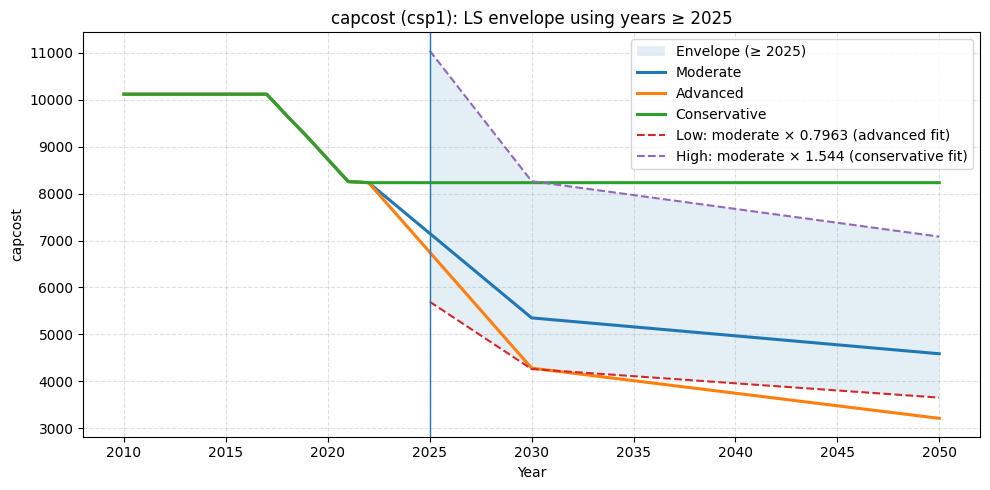

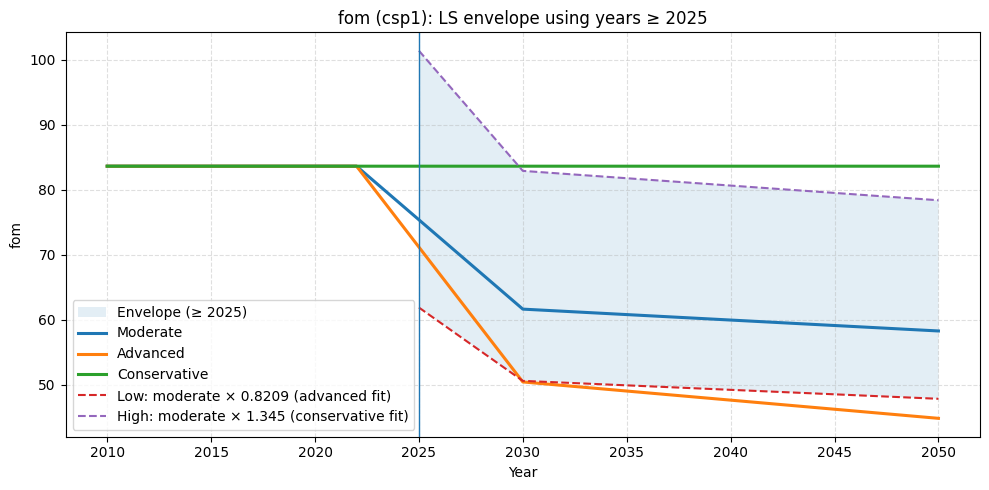

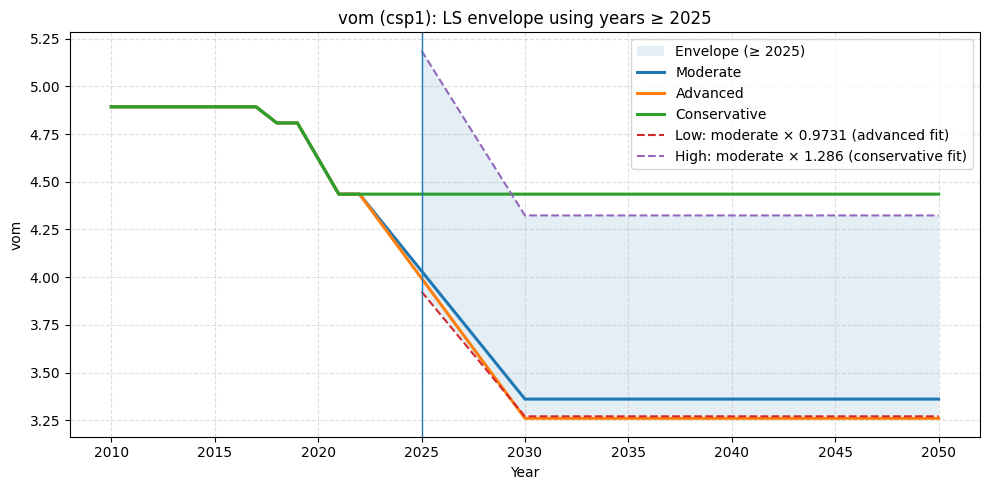

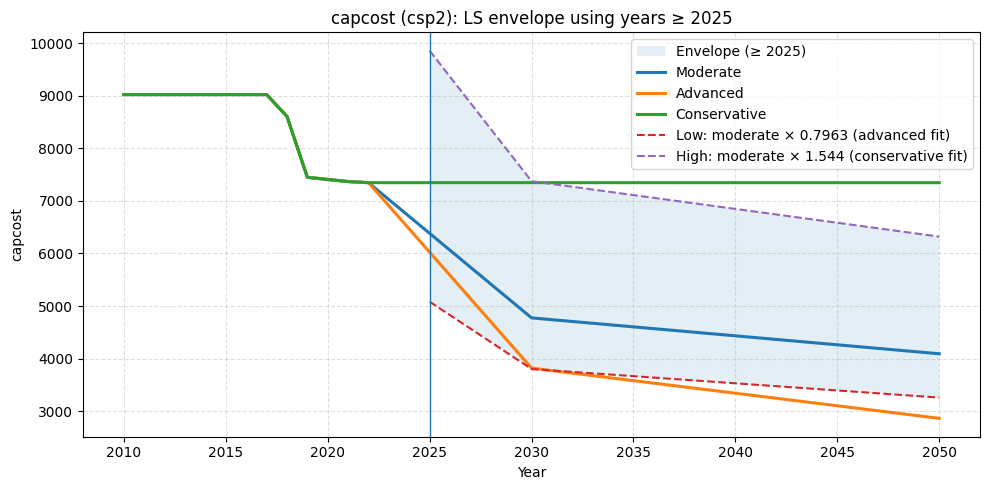

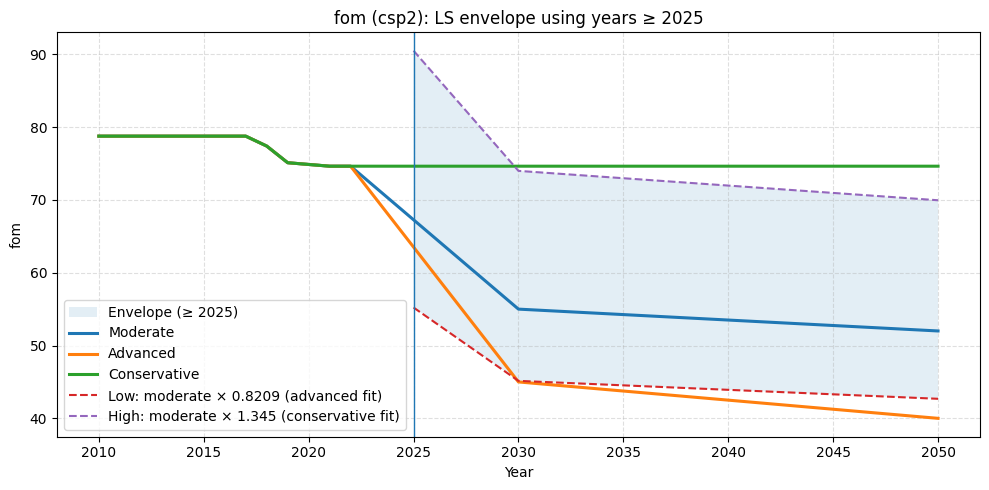

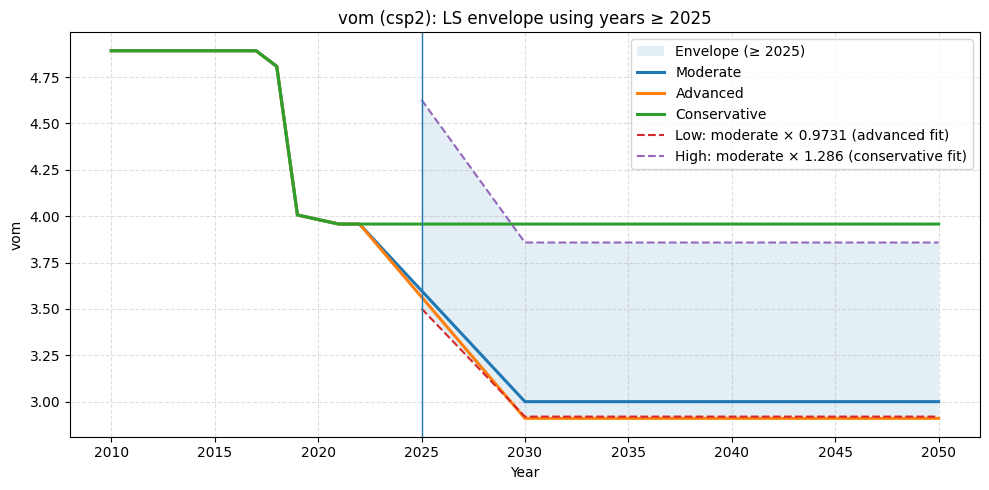

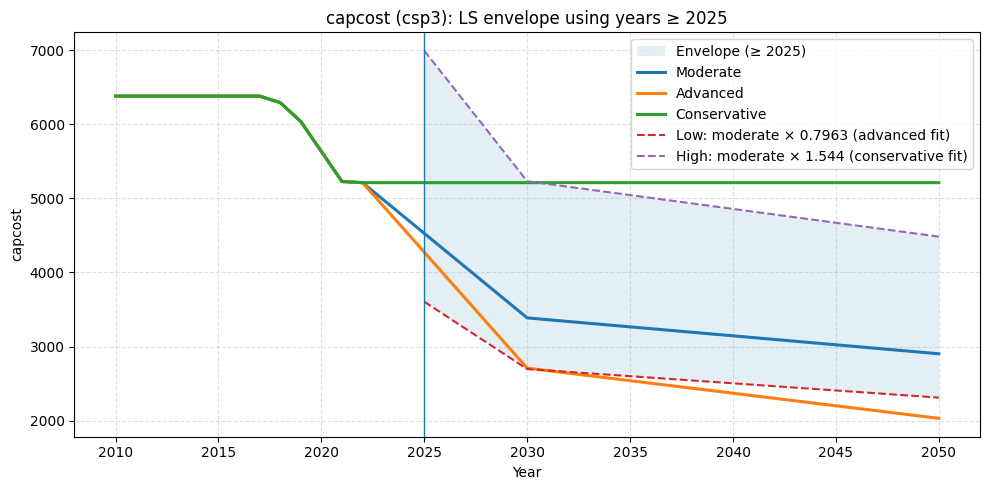

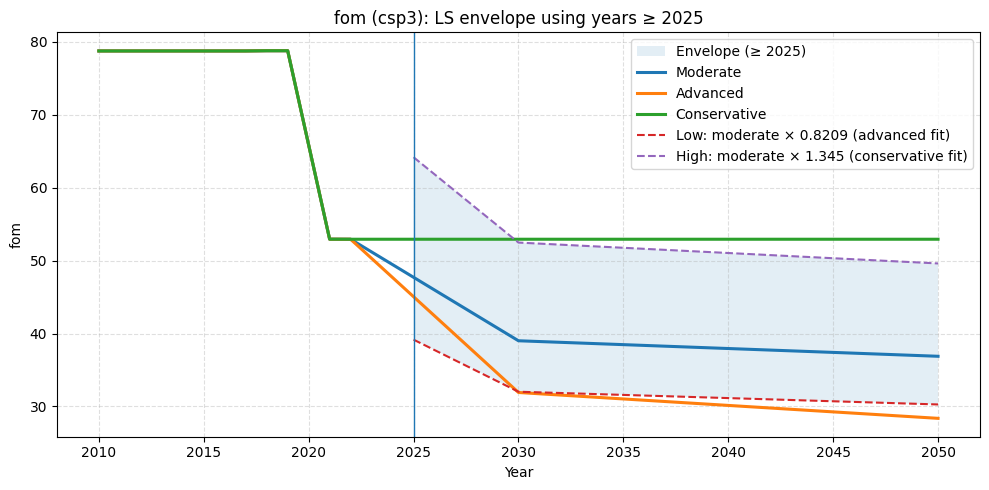

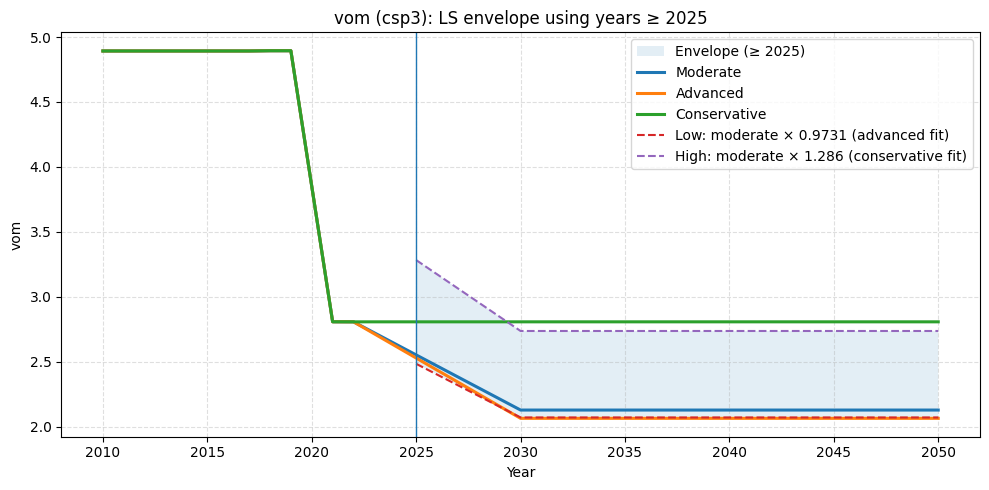

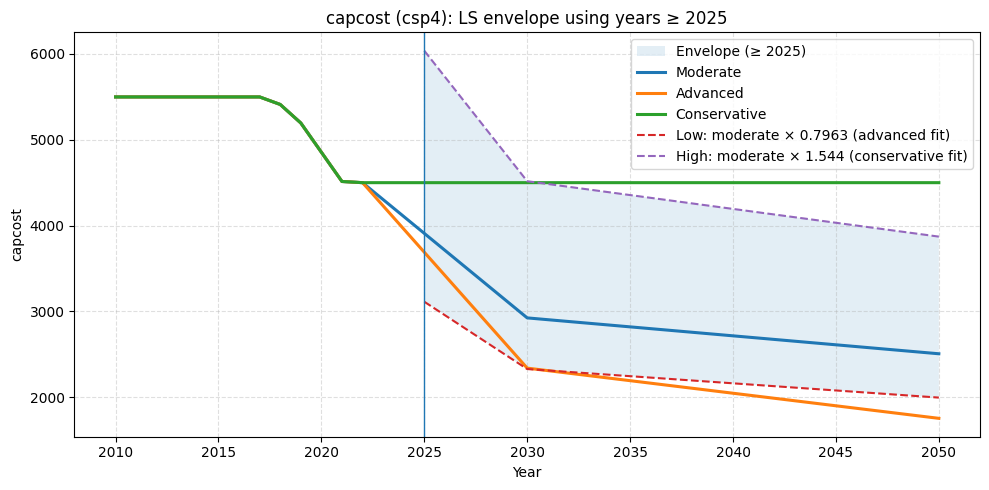

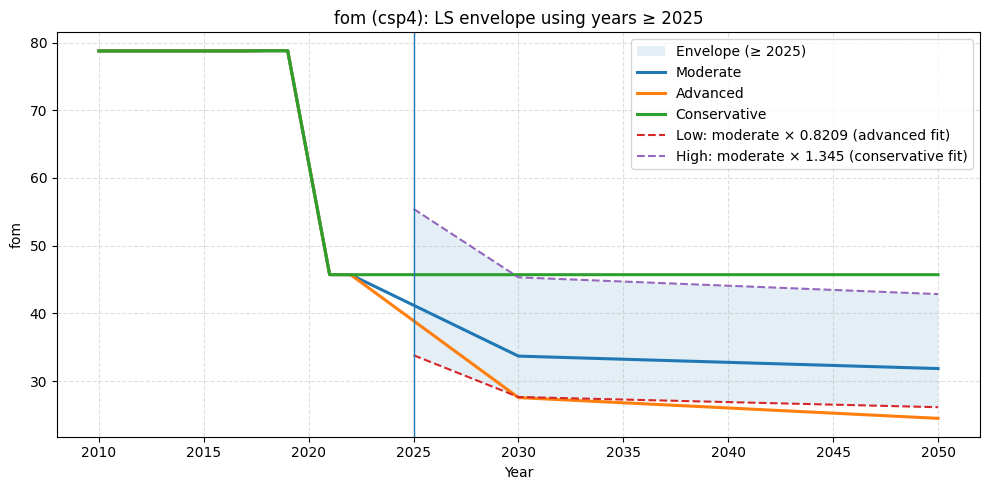

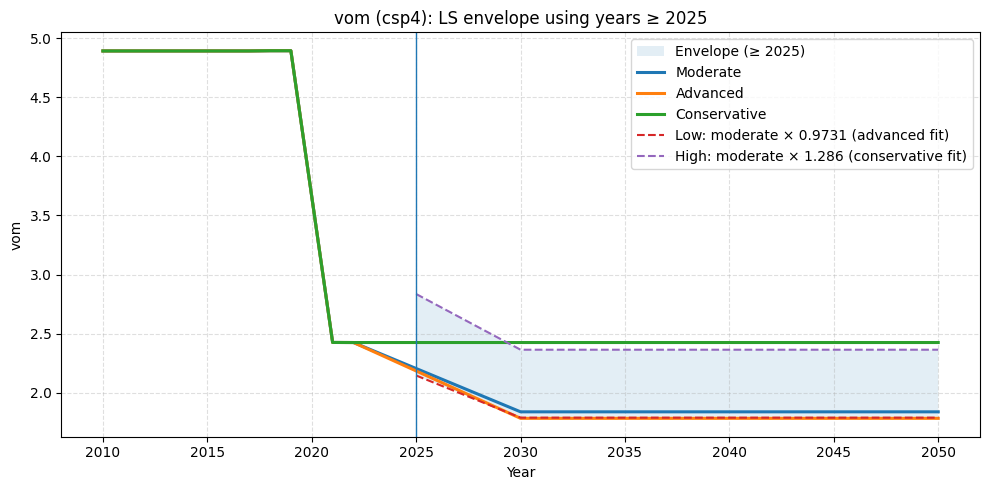

,tech,metric,mA,mC,low_mult,high_mult,low_ref,high_ref,n_years_fit,fit_year_min,fit_year_max
0,csp1,capcost,0.796348,1.544223,0.796348,1.544223,advanced,conservative,26,2025,2050
1,csp1,fom,0.820857,1.345195,0.820857,1.345195,advanced,conservative,26,2025,2050
2,csp1,vom,0.973118,1.286046,0.973118,1.286046,advanced,conservative,26,2025,2050
3,csp2,capcost,0.796348,1.544223,0.796348,1.544223,advanced,conservative,26,2025,2050
4,csp2,fom,0.820857,1.345195,0.820857,1.345195,advanced,conservative,26,2025,2050
5,csp2,vom,0.973118,1.286046,0.973118,1.286046,advanced,conservative,26,2025,2050
6,csp3,capcost,0.796348,1.544223,0.796348,1.544223,advanced,conservative,26,2025,2050
7,csp3,fom,0.820857,1.345195,0.820857,1.345195,advanced,conservative,26,2025,2050
8,csp3,vom,0.973118,1.286046,0.973118,1.286046,advanced,conservative,26,2025,2050
9,csp4,capcost,0.796348,1.544223,0.796348,1.544223,advanced,conservative,26,2025,2050


In [17]:
# Run all techs × metrics, plot, and collect multipliers
results = []
for tech in TECH_LIST:
    for m in METRICS:
        results.append(plot_with_envelope(df, TECH_COL, tech, m, start_year=START_YEAR))

res = pd.DataFrame(results)
res

In [18]:
if SAVE_CSV:
    res.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)

Saved: csp_envelope_multipliers.csv


,sample_id,capcost_mult,fom_mult,vom_mult
0,0,1.375170,1.050978,1.241798
1,1,1.317892,0.870238,1.278418



Done. Wrote 2 sampled files to: /content/sampled_multipliers
Example output preview (sample_000):


,type,t,capcost,fom,vom
0,csp1,2010,10118.392470,83.633963,4.892458
1,csp1,2011,10118.392470,83.633963,4.892458
2,csp1,2012,10118.392470,83.633963,4.892458
3,csp1,2013,10118.392470,83.633963,4.892458
4,csp1,2014,10118.392470,83.633963,4.892458
5,csp1,2015,10118.392470,83.633963,4.892458
6,csp1,2016,10118.392470,83.633963,4.892458
7,csp1,2017,10118.392470,83.633963,4.892458
8,csp1,2018,9655.056558,83.633963,4.807945
9,csp1,2019,9205.528937,83.633963,4.807945


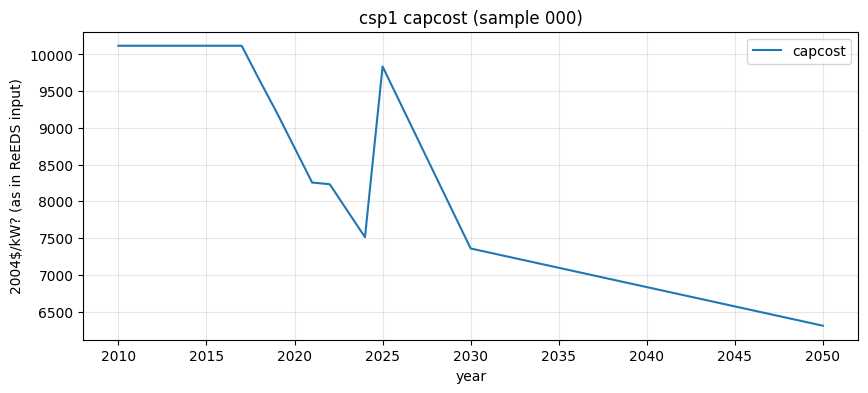

In [19]:
# ---------------------------SET MISSING VARIABLES---------------------------
import pathlib

SEED = 42
N_SAMPLES = 2
OUTDIR = pathlib.Path("sampled_multipliers")
OUTDIR.mkdir(exist_ok=True)

# Compute bounds from the 'res' DataFrame
bounds = {}
for metric in METRICS:
    metric_res = res[res["metric"] == metric]
    # Assuming all techs have the same multipliers for a given metric
    bounds[metric] = (metric_res["low_mult"].min(), metric_res["high_mult"].max())

df_all = df # df_all was not defined, use the previously loaded 'df' variable
# ---------------------------------------------------------------------------

# ---------------------------
# 4) SAMPLE MULTIPLIERS (ONE PER METRIC) -> LIST FORMAT
#     (Uniform sampling inside bounds; you can swap to LHS/triangular if desired)
# ---------------------------
rng = np.random.default_rng(SEED)

samples = []
for s in range(N_SAMPLES):
    draw = {
        "sample_id": s,
        "capcost_mult": float(rng.uniform(*bounds["capcost"])),
        "fom_mult": float(rng.uniform(*bounds["fom"])),
        "vom_mult": float(rng.uniform(*bounds["vom"])),
    }
    samples.append(draw)

# list format requested
samples[:5], len(samples)

samples_df = pd.DataFrame(samples)
display(samples_df.head(10))

# Optional: save the sampling plan
samples_df.to_csv(OUTDIR / "csp_ATB_2024_sampling_plan.csv", index=False)

# ---------------------------
# 5) BUILD BASE MODERATE TABLE AND APPLY MULTIPLIERS TO ALL CSP CLASSES
#     Output CSV(s): type,t,capcost,fom,vom
# ---------------------------
df_mod = df_all[df_all["scenario"] == "moderate"].copy()
df_mod = df_mod.rename(columns={TECH_COL: "type"})
df_mod = df_mod[["type", "t"] + METRICS].copy()

# ensure numeric
for m in METRICS:
    df_mod[m] = pd.to_numeric(df_mod[m], errors="coerce")

# ---------------------------
# 6) GENERATE OUTPUTS LIKE THE GITHUB FORMAT
#     - One CSV per sample:
#         csp_ATB_2024_sample_000.csv, csp_ATB_2024_sample_001.csv, ...
# ---------------------------
for d in samples:
    sid = d["sample_id"]
    out = df_mod.copy()

    # Create a mask for years >= START_YEAR
    mask = out["t"] >= START_YEAR

    # Apply multipliers only to rows where the mask is True
    out.loc[mask, "capcost"] = out.loc[mask, "capcost"] * d["capcost_mult"]
    out.loc[mask, "fom"]     = out.loc[mask, "fom"]     * d["fom_mult"]
    out.loc[mask, "vom"]     = out.loc[mask, "vom"]     * d["vom_mult"]

    # reorder to match GitHub style
    out = out[["type", "t", "capcost", "fom", "vom"]].sort_values(["type", "t"]).reset_index(drop=True)

    # write
    out_path = OUTDIR / f"csp_ATB_2024_sample_{sid:03d}.csv"
    out.to_csv(out_path, index=False)

print(f"\nDone. Wrote {N_SAMPLES} sampled files to: {OUTDIR.resolve()}")
print("Example output preview (sample_000):")
display(pd.read_csv(OUTDIR / "csp_ATB_2024_sample_000.csv").head(20))

# ---------------------------
# 7) (OPTIONAL) QUICK CHECK PLOT FOR ONE TECH CLASS (e.g., csp1) AND ONE SAMPLE
# ---------------------------
CHECK_TYPE = "csp1"
CHECK_SAMPLE = 0

tmp = pd.read_csv(OUTDIR / f"csp_ATB_2024_sample_{CHECK_SAMPLE:03d}.csv")
tmp = tmp[tmp["type"] == CHECK_TYPE].copy()

plt.figure(figsize=(10,4))
plt.plot(tmp["t"], tmp["capcost"], label="capcost")
plt.title(f"{CHECK_TYPE} capcost (sample {CHECK_SAMPLE:03d})")
plt.xlabel("year")
plt.ylabel("2004$/kW? (as in ReEDS input)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [20]:
from IPython.display import Markdown, display

# Units of the underlying parameters (multipliers themselves are unitless)
metric_units = {
    "capcost": r"\$/kW",
    "fom": r"\$/kW-yr",
    "vom": r"\$/MWh",
}

latex_rows = []
for metric, (low_mult, high_mult) in bounds.items():
    parameter = rf"CSP -- {metric}"
    unit = metric_units.get(metric, "unitless")

    # Upperbound then Lowerbound (your preferred order)
    latex_rows.append(
        rf"{parameter} & {high_mult:.4f} & {low_mult:.4f} & {unit} (multiplier) \\"
    )

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Sampled Multiplier Bounds and Parameter Units for CSP ATB 2024}}
\label{{tab:csp_metric_bounds_units}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(f"```latex\n{full_latex_table}\n```"))


```latex

\begin{table}[h!]
\centering
\caption{Sampled Multiplier Bounds and Parameter Units for CSP ATB 2024}
\label{tab:csp_metric_bounds_units}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
CSP -- capcost & 1.5442 & 0.7963 & \$/kW (multiplier) \\
CSP -- fom & 1.3452 & 0.8209 & \$/kW-yr (multiplier) \\
CSP -- vom & 1.2860 & 0.9731 & \$/MWh (multiplier) \\
\bottomrule
\end{tabular}
\end{table}

```

In [21]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# CSP ATB 2024 — Morris-based CSV generation
#   - Base file columns EXACTLY: type,t,capcost,fom,vom
#   - Applies multipliers for years >= APPLY_FROM_YEAR
#   - One output CSV per Morris row (e.g., 200 files)
#   - Output columns/order match the base moderate file exactly
# ============================================================

# -----------------------------
# CONFIG (edit only if needed)
# -----------------------------
APPLY_FROM_YEAR = 2025  # apply for t >= 2025 (set to 2026 if you want t > 2025)

MORRIS_DESIGN_URL = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv#/"
FACTOR_MAP_URL    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv#/"

# If you want to load CSP moderate directly from NREL GitHub (recommended for exact format):
CSP_MODERATE_URL  = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/csp_ATB_2024_moderate.csv"

OUT_DIR = Path("csp_ATB_2024_morris_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_MANIFEST = True
MANIFEST_CSV = OUT_DIR / "csp_ATB_2024_morris_manifest.csv"

# Metrics in CSP file
METRICS = ["capcost", "fom", "vom"]

# -----------------------------
# 1) Load Morris design + factor map
# -----------------------------
design = pd.read_csv(MORRIS_DESIGN_URL)
factor_map = pd.read_csv(FACTOR_MAP_URL)

# -----------------------------
# 2) Load the CSP moderate base EXACTLY like NREL
# -----------------------------
base = pd.read_csv(CSP_MODERATE_URL)

# Enforce exact columns expected by ReEDS / NREL file
expected_cols = ["type", "t", "capcost", "fom", "vom"]
if list(base.columns) != expected_cols:
    raise ValueError(
        "Base CSP moderate file does not match expected columns/order.\n"
        f"Expected: {expected_cols}\n"
        f"Found:    {list(base.columns)}"
    )

base["t"] = base["t"].astype(int)
BASE_COL_ORDER = list(base.columns)

# -----------------------------
# 3) Resolve which Morris design column corresponds to each CSP metric
# -----------------------------
def _find_col_case_insensitive(df: pd.DataFrame, name: str):
    m = {c.lower(): c for c in df.columns}
    return m.get(name.lower(), None)

def resolve_design_col_for(metric: str) -> str:
    """
    Tries to find the design column for CSP metric using:
      - direct names like "CSP__capcost" / "CSP--capcost" / "CSP_capcost"
      - or via factor_map, if it contains a parameter string like "CSP -- capcost"
        and a factor id that appears as a design column.
    """
    # (A) Direct common patterns
    direct_candidates = [
        f"CSP__{metric}",
        f"CSP--{metric}",
        f"CSP_{metric}",
        f"CSP {metric}",
    ]
    for cand in direct_candidates:
        c = _find_col_case_insensitive(design, cand)
        if c is not None:
            return c

    # (B) Factor-map based: find a row mentioning CSP + metric, then map its factor id to a design column
    param_col = None
    for pc in ["parameter", "Parameter", "name", "Name", "desc", "description"]:
        if pc in factor_map.columns:
            param_col = pc
            break

    factor_col = None
    for fc in ["factor", "Factor", "id", "ID"]:
        if fc in factor_map.columns:
            factor_col = fc
            break

    if param_col is not None and factor_col is not None:
        mask = (
            factor_map[param_col].astype(str).str.contains("CSP", case=False, na=False) &
            factor_map[param_col].astype(str).str.contains(metric, case=False, na=False)
        )
        hits = factor_map.loc[mask]
        if len(hits) > 0:
            f = str(hits.iloc[0][factor_col])
            # factor id might be like "p12" or "x12" etc.
            # try direct and case-insensitive
            c = _find_col_case_insensitive(design, f)
            if c is not None:
                return c
            if f in design.columns:
                return f

    raise ValueError(
        f"Could not resolve Morris design column for CSP metric '{metric}'.\n"
        "Fix options:\n"
        "  - Rename your design columns to CSP__capcost, CSP__fom, CSP__vom, OR\n"
        "  - Ensure morris_factor_map has a 'parameter' column containing 'CSP' and the metric name,\n"
        "    plus a 'factor' column whose IDs match columns in morris_design.\n"
        f"Design columns preview: {list(design.columns)[:30]}"
    )

design_cols = {m: resolve_design_col_for(m) for m in METRICS}
print("Resolved Morris design columns:")
for k, v in design_cols.items():
    print(f"  {k} -> {v}")

# -----------------------------
# 4) Apply multipliers to base (years >= APPLY_FROM_YEAR) and write 1 CSV per row
# -----------------------------
def apply_csp_multipliers(base_df: pd.DataFrame, mults: dict, apply_from_year: int) -> pd.DataFrame:
    out = base_df.copy()
    mask = out["t"].astype(int) >= int(apply_from_year)

    for metric, mult in mults.items():
        out.loc[mask, metric] = out.loc[mask, metric].astype(float) * float(mult)

    # enforce EXACT same column order
    out = out[BASE_COL_ORDER]
    return out

manifest = []
for ridx, row in design.reset_index(drop=True).iterrows():
    mults = {m: float(row[design_cols[m]]) for m in METRICS}

    df_out = apply_csp_multipliers(base, mults, APPLY_FROM_YEAR)

    fname = f"csp_ATB_2024_morris_{ridx:03d}.csv"
    fpath = OUT_DIR / fname
    df_out.to_csv(fpath, index=False, float_format="%.6f")

    rec = {"morris_row": ridx, "file": fname, "apply_from_year": APPLY_FROM_YEAR}
    for m in METRICS:
        rec[f"CSP__{m}_mult"] = mults[m]
    manifest.append(rec)

manifest_df = pd.DataFrame(manifest)
if SAVE_MANIFEST:
    manifest_df.to_csv(MANIFEST_CSV, index=False)

print(f"\nDone. Wrote {len(manifest_df)} CSP Morris files to:\n  {OUT_DIR.resolve()}")
print(f"Manifest:\n  {MANIFEST_CSV}")

# -----------------------------
# 5) Safety check: output file columns EXACTLY match NREL moderate
# -----------------------------
def validate_file(fp: Path, expected_cols: list[str]):
    tmp = pd.read_csv(fp)
    if list(tmp.columns) != expected_cols:
        raise ValueError(
            f"Column mismatch in {fp.name}\n"
            f"Expected: {expected_cols}\n"
            f"Found:    {list(tmp.columns)}"
        )

validate_file(OUT_DIR / "csp_ATB_2024_morris_000.csv", expected_cols)
validate_file(OUT_DIR / f"csp_ATB_2024_morris_{len(manifest_df)-1:03d}.csv", expected_cols)
print("Validation passed: output columns/order match NREL moderate exactly.")

# Optional preview
display(pd.read_csv(OUT_DIR / "csp_ATB_2024_morris_000.csv").head(15))


Resolved Morris design columns:
  capcost -> csp_capcost
  fom -> csp_fom
  vom -> csp_vom

Done. Wrote 200 CSP Morris files to:
  /content/csp_ATB_2024_morris_outputs
Manifest:
  csp_ATB_2024_morris_outputs/csp_ATB_2024_morris_manifest.csv
Validation passed: output columns/order match NREL moderate exactly.


,type,t,capcost,fom,vom
0,csp1,2010,10118.392470,83.633963,4.892458
1,csp1,2011,10118.392470,83.633963,4.892458
2,csp1,2012,10118.392470,83.633963,4.892458
3,csp1,2013,10118.392470,83.633963,4.892458
4,csp1,2014,10118.392470,83.633963,4.892458
5,csp1,2015,10118.392470,83.633963,4.892458
6,csp1,2016,10118.392470,83.633963,4.892458
7,csp1,2017,10118.392470,83.633963,4.892458
8,csp1,2018,9655.056558,83.633963,4.807945
9,csp1,2019,9205.528937,83.633963,4.807945


In [22]:
from pathlib import Path
import shutil

OUT_DIR = Path("csp_ATB_2024_morris_outputs")  # <- must match your script
zip_name = "csp_ATB_2024_morris_outputs"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: csp_ATB_2024_morris_outputs.zip
